In [3]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
فروشگاه محصولات اداری
</font>
</h1>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین داده‌های مربوط به یک فروشگاه لوازم اداری به شما داده شده است.
نخست داده‌ها را از فایل 
<code>Superstore.xlsx</code>
بخوانید و در متغیر <code>df</code> بریزید.
</font>
</p>

In [4]:
df = pd.read_csv('SuperStore.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [6]:
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code       float64
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
dtype: object

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,32559.000000,5777.000000,32559.000000,32559.000000,32559.000000,32559.000000,32559.000000
mean,25434.197181,54629.369742,329.794771,3.681931,0.198735,36.648956,35.197700
std,14681.921325,31258.664829,583.220626,2.384490,0.239809,218.195871,68.389523
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12905.500000,23434.000000,37.518000,2.000000,0.000000,-11.056500,3.170000
50%,25154.000000,55901.000000,131.580000,3.000000,0.100000,7.104000,11.510000
75%,38078.000000,85224.000000,378.810000,5.000000,0.400000,68.700000,36.220000
max,51288.000000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000



<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
حالا با استفاده از کتابخانه plt نمودار سود (profit) رادر یک نمودار هیستوگرام رسم کنید.
تعداد ستون ها را حداقل 250 تا در نظر بگیرید.
هم چنین برای مشاهده بهتر نمودار، بازه سود را محدودتر کنید.
</font>
</p>

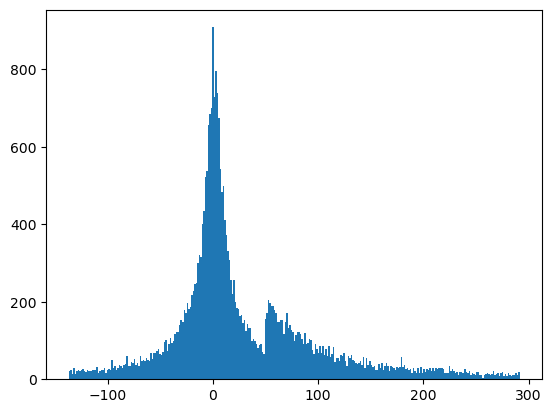

In [8]:
lower_bound = df['Profit'].quantile(0.05)
upper_bound = df['Profit'].quantile(0.95)

bins = np.linspace(lower_bound, upper_bound, 300)
plt.hist(df['Profit'], bins=bins )
plt.show()


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>در این سوال میخواهیم شما ۲ فرضیه را مورد ارزیابی قرار دهید و نتایج خود را برای ما شرح دهید .</font>
</p>


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3> در انتخاب مدل برای تست فرض و همچنین داده‌های لازم برای انجام تست بسیار دقت کنید .</font>
</p>



<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3> برای فرض اول لازم است که سطرهای دیتافریم را طبق ستون نوع ارسال از هم جدا کنید.. </font>
</p><p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3> برای فرض دوم هم لازم است که فروش‌های با تخفیف را از بدون تخفیف‌ها جدا کنید. </font>
</p>

In [9]:
df["Ship Mode"].unique()

array(['Same Day', 'Second Class', 'First Class', 'Standard Class'],
      dtype=object)

In [10]:
df["Discount"].dtype

dtype('float64')

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>فرضیه اول</b>
</font>
</h2>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>
از شما میخواهیم که بررسی کنید که آیا روش ارسال‌های متفاوت (Ship Mode) روی میزان سودی که فروشگاه به دست می‌آورد تاثیرگذار است یا خیر؛
برای این کار دو حالت ‍‍First Class و Standard Class را با هم مقایسه کنید.
</font>
</p>

In [11]:
ship_mode_grouped = df.groupby("Ship Mode")
ship_mode_grouped.get_group('First Class').head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.971,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.540,910.16,Medium
6,30570,IN-2011-81826,2011-11-07,2011-11-09,First Class,TS-21340,Toby Swindell,Consumer,Porirua,Wellington,...,FUR-CH-10004050,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable",1822.080,4,0.0,564.840,894.77,Critical
11,28879,ID-2012-28402,2012-04-19,2012-04-22,First Class,AJ-10780,Anthony Jacobs,Corporate,Kabul,Kabul,...,FUR-TA-10001889,Furniture,Tables,"Bevis Conference Table, Fully Assembled",4626.150,5,0.0,647.550,835.57,High
19,46630,PL-2012-7820,2012-08-08,2012-08-10,First Class,AB-600,Ann Blume,Corporate,Bytom,Silesia,...,FUR-HON-10000224,Furniture,Tables,"Hon Computer Table, with Bottom Storage",1977.720,4,0.0,276.840,759.47,Critical


In [12]:
first_class = ship_mode_grouped.get_group('First Class')
standard_class = ship_mode_grouped.get_group('Standard Class')

In [13]:
count_f = first_class.shape[0]
mean_f = first_class['Profit'].mean()
median_f = first_class['Profit'].median()
std_f = first_class['Profit'].std()

print(f"First Class Count: {count_f}")
print(f'Profit Mean: {np.round(mean_f, 3)}')
print(f'Profit Median: {np.round(median_f, 3)}')
print(f'Profit Std: {np.round(std_f, 3)}')

First Class Count: 4822
Profit Mean: 34.951
Profit Median: 6.608
Profit Std: 224.092


In [14]:
count_s = standard_class.shape[0]
mean_s = standard_class['Profit'].mean()
median_s = standard_class['Profit'].median()
std_s = standard_class['Profit'].std()

print(f"Standard Class Count: {count_s}")
print(f'Profit Mean: {np.round(mean_s, 3)}')
print(f'Profit Median: {np.round(median_s, 3)}')
print(f'Profit Std: {np.round(std_s, 3)}')

Standard Class Count: 19565
Profit Mean: 37.119
Profit Median: 7.2
Profit Std: 217.258


In [ ]:
print("""
    The null hypothesis states that the shipping method has no effect on profit mean.
""")


    The null hypothesis states that the shipping method has no effect on profit.



In [14]:
t_stat, p_value = ttest_ind(first_class['Profit'], standard_class['Profit'], equal_var=False)
print(f"t-stat: {t_stat}")
print(f"p-value: {p_value}")

t-stat: -0.6054147512542649
p-value: 0.5449224864478339


In [ ]:
print("""
    We don't have enough evidence to reject null hypothesis.
""")

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
<b>فرضیه دوم</b>
</font>
</h2>


<p dir=rtl style="direction: rtl; text-align: justify; line-height:200%; font-family:vazir; font-size:medium">
<font face="vazir" size=3>از شما میخواهیم تا بررسی کنید آیا تخفیف‌دار کردن محصولات باعث افزایش تعداد کالا های خریداری شده از یک نوع (Quantity) در فروشگاه خواهد شد یا خیر</font>
</p>

In [18]:
df["Discount Bool"] = np.where(df["Discount"] == 0, 'No Discount', 'Discount')

In [19]:
df.groupby("Discount Bool")['Quantity'].agg(['count','mean','std'])

,count,mean,std
Discount Bool,,,
Discount,17723,3.609152,2.304782
No Discount,14836,3.768873,2.473622


In [20]:
with_discount = df.loc[df["Discount Bool"] == "Discount"]['Quantity']
without_discount = df.loc[df["Discount Bool"] == "No Discount"]["Quantity"]

In [21]:
print("""
    The null hypothesis states that the Discount has no effect on Quantity mean.
""")


    The null hypothesis states that the Discount has no effect on Quantity mean.



In [22]:
t_stat, p_value = ttest_ind(with_discount, without_discount, equal_var=False)
print(f"t-stat: {t_stat}")
print(f"p-value: {p_value}")
print(p_value < 0.05)

t-stat: -5.98515216822144
p-value: 2.185849769286878e-09
True


In [23]:
print("""
    We can reject null hypothesis and say probably Discount has negative relation with Quantity
""")


    We can reject null hypothesis and say probably Discount has negative relation with Quantity

